# Bloque I — Python, pandas y análisis descriptivo

**Duración estimada:** 3 horas  
**Modalidad:** explicación + demostración guiada + práctica individual  
**Dataset:** `../data/ventas_mayo_2026.csv`

## Objetivo de aprendizaje

Al finalizar la sesión, el alumnado será capaz de cargar, inspeccionar, limpiar, transformar, describir y visualizar un dataset tabular con Python y `pandas`, generando conclusiones iniciales útiles para un proyecto de análisis de datos.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:20 | Ecosistema Python para análisis de datos |
| 0:20–0:50 | Repaso de estructuras básicas de Python |
| 0:50–1:25 | Introducción práctica a `numpy` y `pandas` |
| 1:25–1:35 | Pausa |
| 1:35–2:15 | Carga, exploración y limpieza de datos |
| 2:15–2:45 | Análisis descriptivo y visualización |
| 2:45–3:00 | Ejercicio integrador y conclusiones |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Repaso aplicado de Python

En análisis de datos no se necesita dominar todo Python desde el primer día, pero sí comprender las estructuras que se usarán de forma continua:

- variables,
- listas,
- diccionarios,
- condicionales,
- bucles,
- funciones.

La idea importante es que Python permite expresar reglas de negocio y transformaciones de datos de forma clara.

In [2]:
edad = 35
nombre = "Cliente A"
importe = 1250.75

ventas_lista = [120, 150, 180, 90, 210]

cliente = {
    "id": 1,
    "nombre": "Cliente A",
    "segmento": "Premium",
    "ventas": 1250
}

def clasificar_cliente(importe):
    if importe >= 1000:
        return "Alto valor"
    elif importe >= 500:
        return "Valor medio"
    else:
        return "Valor bajo"

for venta in ventas_lista:
    print(venta, "->", clasificar_cliente(venta))

120 -> Valor bajo
150 -> Valor bajo
180 -> Valor bajo
90 -> Valor bajo
210 -> Valor bajo


## 2. Introducción a NumPy

`numpy` permite trabajar con arrays y operaciones vectorizadas. Esto es clave porque en análisis de datos se procesan columnas completas, no elemento a elemento.

In [3]:
ventas_array = np.array([120, 150, 180, 90, 210])

print("Media:", np.mean(ventas_array))
print("Mediana:", np.median(ventas_array))
print("Desviación típica:", np.std(ventas_array))
print("Ventas con IVA:", ventas_array * 1.21)

Media: 150.0
Mediana: 150.0
Desviación típica: 42.42640687119285
Ventas con IVA: [145.2 181.5 217.8 108.9 254.1]


## 3. Carga de datos con pandas

`pandas` es la librería principal para trabajar con datos tabulares. Su estructura central es el `DataFrame`, equivalente a una tabla con filas y columnas.

In [4]:
df = pd.read_csv("../data/ventas_mayo_2026.csv")
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,101.550"


In [5]:
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (505, 10)
<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fecha                     505 non-null    str    
 1   cliente_id                505 non-null    str    
 2   categoria                 505 non-null    str    
 3   region                    495 non-null    str    
 4   canal                     505 non-null    str    
 5   unidades                  505 non-null    int64  
 6   precio_unitario           490 non-null    float64
 7   descuento                 505 non-null    float64
 8   antiguedad_cliente_meses  505 non-null    int64  
 9   importe                   505 non-null    float64
dtypes: float64(3), int64(2), str(5)
memory usage: 39.6 KB


## 4. Exploración inicial

Antes de limpiar o modelizar, debemos entender el dataset:

- qué columnas tiene,
- qué tipo de datos contiene,
- cuántos registros hay,
- si hay valores nulos,
- si existen duplicados,
- qué rango tienen las variables numéricas.

In [6]:
display(df.describe(include="all"))
print("\nValores nulos por columna:")
display(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
count,505,505,505,495,505,505.000,490.000,505.000,505.000,505.000
unique,500,500,5,5,3,NaN,NaN,NaN,NaN,NaN
top,2025-02-17,C1047,Alimentación,Madrid,Online,NaN,NaN,NaN,NaN,NaN
freq,2,2,122,108,212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,8.859,136.636,0.069,35.996,"1,226.787"
std,NaN,NaN,NaN,NaN,NaN,2.877,92.908,0.041,20.486,896.936
min,NaN,NaN,NaN,NaN,NaN,2.000,-4.950,0.000,1.000,20.000
25%,NaN,NaN,NaN,NaN,NaN,7.000,56.485,0.040,18.000,521.850
50%,NaN,NaN,NaN,NaN,NaN,9.000,118.305,0.060,36.000,"1,007.810"
75%,NaN,NaN,NaN,NaN,NaN,11.000,194.067,0.090,54.000,"1,742.960"



Valores nulos por columna:


fecha                        0
cliente_id                   0
categoria                    0
region                      10
canal                        0
unidades                     0
precio_unitario             15
descuento                    0
antiguedad_cliente_meses     0
importe                      0
dtype: int64


Duplicados: 5


## 5. Limpieza básica

En un proyecto real, la limpieza debe documentarse. No basta con modificar los datos: hay que explicar qué se ha hecho y por qué.

En este ejemplo:

- eliminamos duplicados,
- convertimos la fecha,
- imputamos valores numéricos con la mediana,
- imputamos valores categóricos con una etiqueta explícita.

In [7]:
df_limpio = df.copy()

# Eliminar duplicados
df_limpio = df_limpio.drop_duplicates()

# Convertir fecha
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

# Imputar nulos
df_limpio["precio_unitario"] = df_limpio["precio_unitario"].fillna(df_limpio["precio_unitario"].median())
df_limpio["region"] = df_limpio["region"].fillna("Sin informar")

# Crear variables derivadas
df_limpio["mes"] = df_limpio["fecha"].dt.month
df_limpio["dia_semana"] = df_limpio["fecha"].dt.day_name()
df_limpio["importe_con_iva"] = df_limpio["importe"] * 1.21
df_limpio["ticket_unitario"] = df_limpio["importe"] / df_limpio["unidades"]

df_limpio.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes,dia_semana,importe_con_iva,ticket_unitario
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250,1,Wednesday,"1,011.862",104.531
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720,1,Thursday,"1,157.631",191.344
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650,1,Friday,432.756,51.093
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520,1,Saturday,364.839,33.502
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.520,0.090,29,"2,101.550",1,Sunday,"2,542.876",262.694


## 6. Análisis descriptivo

El análisis descriptivo resume el comportamiento de los datos. Responde preguntas como:

- ¿cuál es el importe medio?
- ¿qué región vende más?
- ¿qué categoría tiene mayor ticket?
- ¿cómo se distribuyen las ventas?
- ¿existen valores extremos?

In [8]:
metricas_importe = df_limpio["importe"].agg(["count", "mean", "median", "std", "min", "max"])
metricas_importe

count      500.000
mean     1,235.043
median   1,013.780
std        897.348
min         20.000
max      4,409.820
Name: importe, dtype: float64

In [9]:
ventas_por_categoria = (
    df_limpio
    .groupby("categoria")
    .agg(
        ventas_totales=("importe", "sum"),
        importe_medio=("importe", "mean"),
        unidades_totales=("unidades", "sum"),
        operaciones=("cliente_id", "count")
    )
    .sort_values("ventas_totales", ascending=False)
)

ventas_por_categoria

,ventas_totales,importe_medio,unidades_totales,operaciones
categoria,,,,
Tecnología,"276,483.260","2,383.476",1018,116
Servicios,"135,872.490","1,598.500",774,85
Hogar,"104,486.380","1,088.400",866,96
Moda,"56,386.960",671.273,751,84
Alimentación,"44,292.420",372.205,1027,119


In [10]:
ventas_por_region = (
    df_limpio
    .groupby("region")["importe"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_region

region
Madrid               135,096.640
Valencia             130,204.600
Andalucía            123,464.610
Cataluña             106,247.090
Castilla-La Mancha   105,563.350
Sin informar          16,945.220
Name: importe, dtype: float64

## 7. Visualización

La visualización permite detectar patrones rápidamente. En esta sesión se trabajan gráficos básicos pero muy útiles:

- histograma,
- boxplot,
- barras,
- línea temporal.

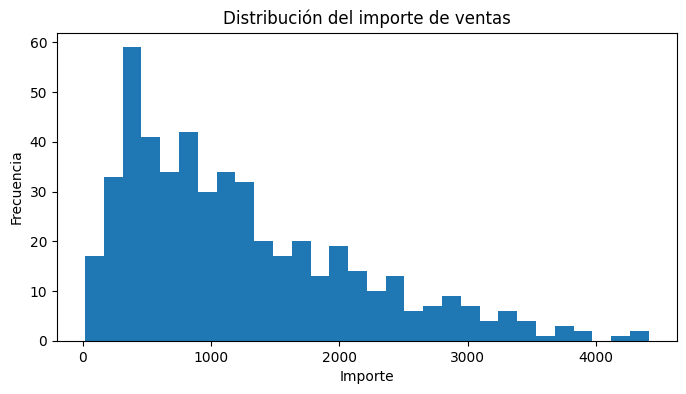

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df_limpio["importe"], bins=30)
plt.title("Distribución del importe de ventas")
plt.xlabel("Importe")
plt.ylabel("Frecuencia")
plt.show()

<Figure size 900x400 with 0 Axes>

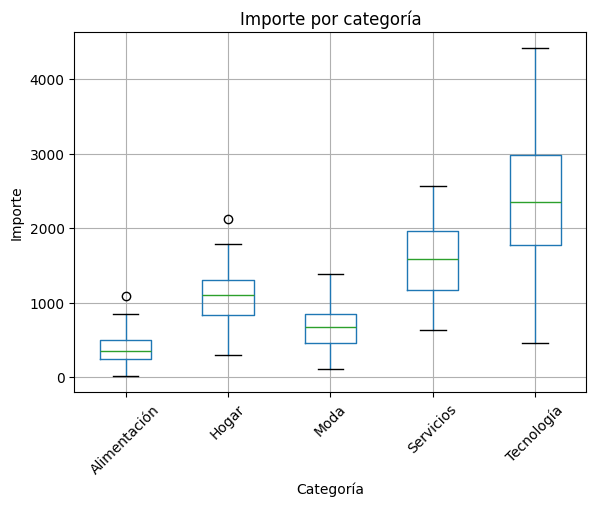

In [12]:
plt.figure(figsize=(9, 4))
df_limpio.boxplot(column="importe", by="categoria", rot=45)
plt.title("Importe por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Importe")
plt.show()

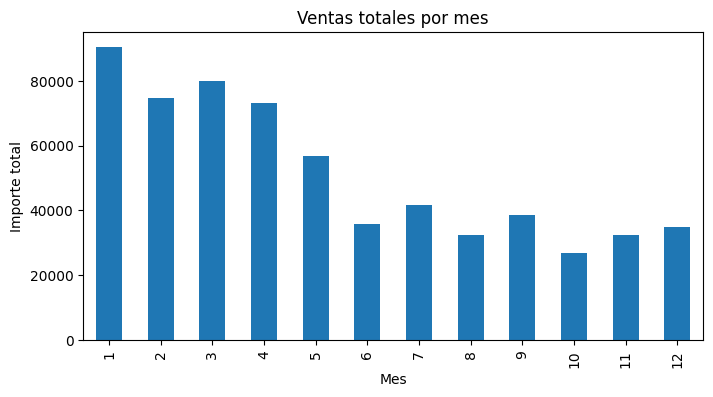

In [13]:
ventas_mes = df_limpio.groupby("mes")["importe"].sum()

plt.figure(figsize=(8, 4))
ventas_mes.plot(kind="bar")
plt.title("Ventas totales por mes")
plt.xlabel("Mes")
plt.ylabel("Importe total")
plt.show()

## 8. Mini-informe automático

Una buena práctica en notebooks docentes es cerrar cada análisis con conclusiones escritas. El código produce números, pero el analista debe convertirlos en interpretación.

In [14]:
categoria_top = ventas_por_categoria.index[0]
region_top = ventas_por_region.index[0]
importe_medio = df_limpio["importe"].mean()

print(f"Conclusión 1: La categoría con mayor venta total es {categoria_top}.")
print(f"Conclusión 2: La región con mayor importe acumulado es {region_top}.")
print(f"Conclusión 3: El importe medio por operación es {importe_medio:,.2f} euros.")

Conclusión 1: La categoría con mayor venta total es Tecnología.
Conclusión 2: La región con mayor importe acumulado es Madrid.
Conclusión 3: El importe medio por operación es 1,235.04 euros.


## 9. Ejercicio integrador

Realiza las siguientes tareas:

1. Calcula las ventas totales por canal.
2. Calcula el ticket medio por región.
3. Identifica la categoría con mayor número de unidades vendidas.
4. Genera un gráfico de barras con las ventas por canal.
5. Redacta tres conclusiones de negocio.

### Entregable

Un notebook con código ejecutable, gráficos y una sección final llamada **Conclusiones**.

Ventas totales por: canal
Online         261,172.610
Tienda         220,217.410
Distribuidor   136,131.490
Name: importe, dtype: float64 

Ventas totales por: region
Sin informar         1,694.522
Valencia             1,276.516
Madrid               1,262.585
Castilla-La Mancha   1,256.707
Andalucía            1,222.422
Cataluña             1,106.741
Name: importe, dtype: float64

Categoría con más unidades vendidas: Alimentación 



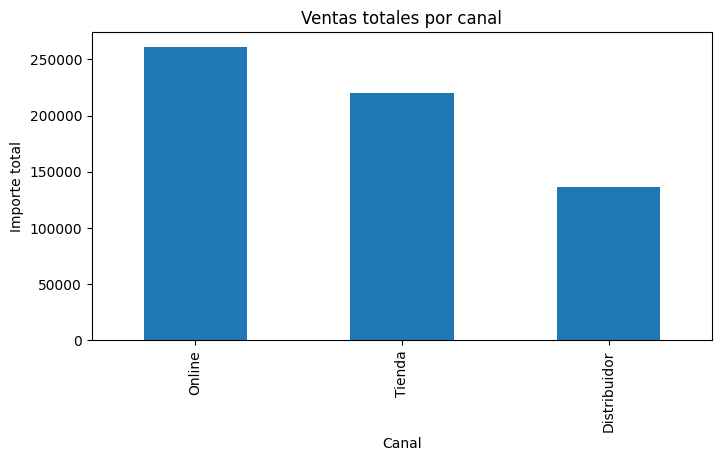

Conclusiones: 
 1. El canal con mayor volumen de ventas es el que genera más ingresos, lo que indica su importancia estratégica. 
 2. Existen diferencias en el ticket medio por región, lo que sugiere comportamientos de consumo distintos según la zona. 
 3. La categoría con mayor número de unidades vendidas refleja la mayor demanda del mercado y podría ser clave para futuras campañas.


In [ ]:
# SELENE INMACULADA GARCÍA CHACÓN

# ---------------------------------------------------------
# AGRUPACIÓN: VENTAS TOTALES POR CANAL
# ---------------------------------------------------------
# Agrupamos los datos por la columna "canal"
# y sumamos el importe total de ventas de cada uno.
# Luego ordenamos de mayor a menor para ver cuál vende más.

ventas_por_canal = (
    df_limpio.groupby("canal")["importe"]  # agrupa por canal y toma la columna importe
    .sum()                                 # suma todo el dinero por canal
    .sort_values(ascending=False)          # ordena de mayor a menor
)

print(f"Ventas totales por canal:\n{ventas_por_canal}\n")


# ---------------------------------------------------------
# AGRUPACIÓN: TICKET MEDIO POR REGIÓN
# ---------------------------------------------------------
# Calculamos cuánto dinero gasta de media cada región por compra.

ticket_medio_region = (
    df_limpio.groupby("region")["importe"]  # agrupa por región
    .mean()                                # calcula la media del importe
    .sort_values(ascending=False)          # ordena de mayor a menor
)

print(f"Ticket medio por región:\n{ticket_medio_region}\n")


# ---------------------------------------------------------
# AGRUPACIÓN: CATEGORÍA CON MÁS UNIDADES VENDIDAS
# ---------------------------------------------------------
# Sumamos cuántas unidades se han vendido por categoría.
# Usamos idxmax() para encontrar la categoría con mayor valor.

unidades_por_categoria = (
    df_limpio.groupby("categoria")["unidades"]  # agrupa por categoría
    .sum()                                     # suma unidades vendidas
    .sort_values(ascending=False)              # ordena de mayor a menor
)

# Obtiene directamente el nombre de la categoría con más unidades
categoria_top = unidades_por_categoria.idxmax()


print(f"Categoría con más unidades vendidas: {categoria_top}\n")


# ---------------------------------------------------------
# VISUALIZACIÓN: VENTAS POR CANAL
# ---------------------------------------------------------
# Creamos un gráfico de barras para ver visualmente
# qué canal tiene más ventas.

plt.figure(figsize=(8,4))               # tamaño del gráfico
ventas_por_canal.plot(kind="bar")       # gráfico de barras
plt.title("Ventas totales por canal")   # título
plt.xlabel("Canal")                     # eje X
plt.ylabel("Importe total")             # eje Y
plt.show()                              # mostrar gráfico


# ---------------------------------------------------------
# CONCLUSIONES FINALES
# ---------------------------------------------------------

print(
    "Conclusiones:\n"
    "1. El canal con mayor volumen de ventas es el que genera más ingresos, lo que indica su importancia estratégica.\n"
    "2. Existen diferencias en el ticket medio por región, lo que sugiere comportamientos de consumo distintos según la zona.\n"
    "3. La categoría con mayor número de unidades vendidas refleja la mayor demanda del mercado y podría ser clave para futuras campañas."
)